<a href="https://colab.research.google.com/github/jespimentel/aula_fucape/blob/main/datajud_tjma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Palestra: "O Poder de IA e do Python na Coleta e Tratamento de Dados Judiciais"
## DataJud na Prática
---

Notebook de referência da palestra de **José Eduardo de Souza Pimentel** na FUCAPE - Jun. 2026

---
Vamos sair de uma consulta simples (de um único processo) e seguir até a análise exploratória de todos os processos de uma vara específica, com gráficos em `pandas` + `matplotlib`.

# 1. Importações e configurações necessárias

Importamos as bibliotecas e definimos a URL e a chave pública de acesso ao TJSP. A `ApiKey` usada aqui é a **chave pública** divulgada pelo CNJ.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json

In [ ]:
url = "https://api-publica.datajud.cnj.jus.br/api_publica_tjma/_search"
api_key = "APIKey cDZHYzlZa0JadVREZDJCendQbXY6SkJlTzNjLV9TRENyQk1RdnFKZGRQdw=="  # Chave pública do CNJ

headers = {
    'Authorization': api_key,
    'Content-Type': 'application/json'
}


# 2. A consulta mais básica

In [ ]:
response = requests.post(url, headers=headers)
print(response)

<Response [200]>


In [ ]:
response.text [:1000]

'{"took":6,"timed_out":false,"_shards":{"total":4,"successful":4,"skipped":0,"failed":0},"hits":{"total":{"value":10000,"relation":"gte"},"max_score":1.0,"hits":[{"_index":"api_publica_tjma","_id":"TJMA_G2_08094637920208100000","_score":1.0,"_source":{"numeroProcesso":"08094637920208100000","classe":{"codigo":202,"nome":"Agravo de Instrumento"},"sistema":{"codigo":1,"nome":"PJe"},"formato":{"codigo":1,"nome":"Eletrônico"},"tribunal":"TJMA","dataHoraUltimaAtualizacao":"2026-06-12T19:26:21.469000Z","grau":"G2","@timestamp":"2026-06-12T19:26:21.469000Z","dataAjuizamento":"20200720165707","movimentos":[{"complementosTabelados":[{"codigo":4,"valor":107,"nome":"Certidão","descricao":"tipo_de_documento"}],"codigo":60,"nome":"Expedição de documento","dataHora":"2021-11-22T11:13:07.000Z","orgaoJulgador":{"codigo":"19914","nome":"Gabinete Des. Marcelo Carvalho Silva"}},{"codigo":1051,"nome":"Decurso de Prazo","dataHora":"2021-11-20T01:00:49.000Z","orgaoJulgador":{"codigo":"19914","nome":"Gabinet

In [ ]:
print(response.json())

## 3. Entendendo a resposta

Por 'hits' devemos entender os resultados retornados com a busca (padrão no Elasticsearch).


```python
dados_dict = {
    "took": ...,
    "timed_out": ...,
    "_shards": {...},
    "hits": {                          # <- nível 1: metadados da busca
        "total": {"value": N, ...},
        "max_score": ...,
        "hits": [                      # <- nível 2: lista de resultados
            {
                "_index": "...",
                "_id": "...",
                "_score": ...,
                "_source": { ... }     # <- aqui ficam os dados do processo (classe, assuntos, movimentos etc.)
            },
            ...
        ]
    }
}
```

In [ ]:
processos = response.json()['hits']['hits']
print(f"Total de processos encontrados: {len(processos)}")

Total de processos encontrados: 10


# 4. Gerando o primeiro dataframe

In [ ]:
df = pd.DataFrame(processos)
df.head()

,_index,_id,_score,_source
0,api_publica_tjma,TJMA_G2_08094637920208100000,1.0,"{'numeroProcesso': '08094637920208100000', 'cl..."
1,api_publica_tjma,TJMA_G2_08094117520238100001,1.0,"{'numeroProcesso': '08094117520238100001', 'cl..."
2,api_publica_tjma,TJMA_G2_08094119420198100040,1.0,"{'numeroProcesso': '08094119420198100040', 'cl..."
3,api_publica_tjma,TJMA_G2_08094122020258100024,1.0,"{'numeroProcesso': '08094122020258100024', 'cl..."
4,api_publica_tjma,TJMA_G2_08094122920248100000,1.0,"{'numeroProcesso': '08094122920248100000', 'cl..."


In [ ]:
# "Achatando" hierarquias com o json_normalize()
df = pd.json_normalize(processos)
df.head()

,_index,_id,_score,_source.numeroProcesso,_source.classe.codigo,_source.classe.nome,_source.sistema.codigo,_source.sistema.nome,_source.formato.codigo,_source.formato.nome,...,_source.grau,_source.@timestamp,_source.dataAjuizamento,_source.movimentos,_source.id,_source.nivelSigilo,_source.orgaoJulgador.codigoMunicipioIBGE,_source.orgaoJulgador.codigo,_source.orgaoJulgador.nome,_source.assuntos
0,api_publica_tjma,TJMA_G2_08094637920208100000,1.0,08094637920208100000,202,Agravo de Instrumento,1,PJe,1,Eletrônico,...,G2,2026-06-12T19:26:21.469000Z,20200720165707,"[{'complementosTabelados': [{'codigo': 4, 'val...",TJMA_G2_08094637920208100000,0,2111300,19914,Gabinete Des. Marcelo Carvalho Silva (CCII),"[{'codigo': 9160, 'nome': 'Levantamento de Val..."
1,api_publica_tjma,TJMA_G2_08094117520238100001,1.0,08094117520238100001,198,Apelação Cível,1,PJe,1,Eletrônico,...,G2,2026-06-12T19:26:21.478000Z,20241211135014,"[{'complementosTabelados': [{'codigo': 4, 'val...",TJMA_G2_08094117520238100001,0,2111300,19901,Gabinete Des. Cleones Carvalho Cunha (CDPU),"[{'codigo': 10300, 'nome': 'Data Base'}]"
2,api_publica_tjma,TJMA_G2_08094119420198100040,1.0,08094119420198100040,198,Apelação Cível,1,PJe,1,Eletrônico,...,G2,2026-06-12T19:26:21.484000Z,20220530094024,"[{'complementosTabelados': [{'codigo': 3, 'val...",TJMA_G2_08094119420198100040,0,2111300,83889,Gabinete Des. Douglas Airton Ferreira Amorim (...,"[{'codigo': 7780, 'nome': 'Indenização por Dan..."
3,api_publica_tjma,TJMA_G2_08094122020258100024,1.0,08094122020258100024,198,Apelação Cível,1,PJe,1,Eletrônico,...,G2,2026-06-12T19:26:21.488000Z,20260224090246,"[{'codigo': 1051, 'nome': 'Decurso de Prazo', ...",TJMA_G2_08094122020258100024,0,2111300,19900,Gabinete Des. Antonio Guerreiro Junior - Juiz ...,"[{'codigo': 11806, 'nome': 'Empréstimo consign..."
4,api_publica_tjma,TJMA_G2_08094122920248100000,1.0,08094122920248100000,12394,Revisão Criminal,1,PJe,1,Eletrônico,...,G2,2026-06-12T19:26:21.489000Z,20240422135906,"[{'codigo': 1051, 'nome': 'Decurso de Prazo', ...",TJMA_G2_08094122920248100000,0,2111300,88660,Gabinete Des�. Maria da Gra�a Peres Soares Amo...,"[{'codigo': 5842, 'nome': 'Abuso de Incapazes'}]"


# 5. Refinando a consulta
Acrescentando o payload (blocos opcionais: `size`, `query`e `sort`)
```python
{
  "size": 10,
  "query": {
    "bool": {
      "must": [
        { "match": { "nome_do_campo_1": "valor_procurado" } },
        { "match": { "nome_do_campo_2": "outro_valor" } }
      ]
    }
  },
  "sort": [
    { "campo_data": { "order": "desc" } }
  ]
}
```

In [ ]:
# Consultando um processo específico
numero_processo = '08085076320208100000'  # Exemplo

payload = json.dumps({
    "query": {
        "match": {"numeroProcesso": numero_processo}
    }
})

response = requests.post(url, headers=headers, data=payload)
response.json()

In [ ]:
payload = json.dumps(
{
  "size": 10000,
  "query": {
    "range": {
      "dataAjuizamento": {
        "gte": "20260101000000",
        "lte": "20261231235959"
      }
    }
  },
  "sort": [
    {
      "dataAjuizamento": {
        "order": "desc"
      }
    }
  ]
}
)
response = requests.post(url, headers=headers, data=payload)
response.json()

In [ ]:
# "Achatando" hierarquias com o json_normalize()
df_tjma = pd.json_normalize(response.json()['hits']['hits'])
df_tjma.head()

,_index,_id,_score,sort,_source.numeroProcesso,_source.classe.codigo,_source.classe.nome,_source.sistema.codigo,_source.sistema.nome,_source.formato.codigo,...,_source.grau,_source.@timestamp,_source.dataAjuizamento,_source.movimentos,_source.id,_source.nivelSigilo,_source.orgaoJulgador.codigoMunicipioIBGE,_source.orgaoJulgador.codigo,_source.orgaoJulgador.nome,_source.assuntos
0,api_publica_tjma,TJMA_G2_00487099320128100001,None,[20260609123728],00487099320128100001,198,Apelação Cível,1,PJe,1,...,G2,2026-06-12T18:56:16.321000Z,20260609123728,"[{'complementosTabelados': [{'codigo': 18, 'va...",TJMA_G2_00487099320128100001,0,2111300,19917,Gabinete Des. Paulo S�rgio Velten Pereira (CDPR),"[{'codigo': 9596, 'nome': 'Prestação de Serviç..."
1,api_publica_tjma,TJMA_G1_08005172420268100125,None,[20260608192955],08005172420268100125,283,Ação Penal - Procedimento Ordinário,1,PJe,1,...,G1,2026-06-12T10:17:46.108000Z,20260608192955,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_G1_08005172420268100125,0,2111003,3703,VARA �NICA DA COMARCA DE S�O JO�O BATISTA,"[{'codigo': 3566, 'nome': 'Resistência '}]"
2,api_publica_tjma,TJMA_G1_08115195220268100040,None,[20260608192627],08115195220268100040,1707,Reintegração / Manutenção de Posse,1,PJe,1,...,G1,2026-06-12T15:58:45.616000Z,20260608192627,"[{'complementosTabelados': [{'codigo': 3, 'val...",TJMA_G1_08115195220268100040,0,2105302,2962,3� VARA C�VEL DA COMARCA DE IMPERATRIZ,"[{'codigo': 10445, 'nome': 'Esbulho / Turbação..."
3,api_publica_tjma,TJMA_JE_08006890220268100016,None,[20260608192333],08006890220268100016,12154,Execução de Título Extrajudicial,1,PJe,1,...,JE,2026-06-11T07:24:59.315000Z,20260608192333,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_JE_08006890220268100016,0,2111300,3078,11� JUIZADO ESPECIAL C�VEL E DAS RELA��ES DE C...,"[{'codigo': 9581, 'nome': 'Agência e Distribui..."
4,api_publica_tjma,TJMA_TR_08001929620268109001,None,[20260608192101],08001929620268109001,120,Mandado de Segurança Cível,1,PJe,1,...,TR,2026-06-12T18:35:06.672000Z,20260608192101,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_TR_08001929620268109001,0,2111300,81263,2� TURMA RECURSAL PERMANENTE DO TERMO JUDICI�R...,"[{'codigo': 9196, 'nome': 'Liminar '}]"


In [ ]:
# Temos um problema aqui? 10000 processos.
df_tjma.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   _index                                     10000 non-null  object
 1   _id                                        10000 non-null  object
 2   _score                                     0 non-null      object
 3   sort                                       10000 non-null  object
 4   _source.numeroProcesso                     10000 non-null  object
 5   _source.classe.codigo                      10000 non-null  object
 6   _source.classe.nome                        10000 non-null  object
 7   _source.sistema.codigo                     10000 non-null  int64 
 8   _source.sistema.nome                       10000 non-null  object
 9   _source.formato.codigo                     10000 non-null  int64 
 10  _source.formato.nome               

# 6. Uma função para permitir a paginação (`search_after`)

A documentação do DataJud traz uma regra de negócio muito específica (e obrigatória) para que o `search_after` funcione corretamente na infraestrutura deles: a utilização da ordenação (sort) dos dados utilizando o atributo `@timestamp`.

In [ ]:
def buscar_mais_processos(url, headers, query, tamanho_pagina=10000, limite_maximo=None):
    """
    Função genérica para a busca de processos na API do DataJud com uso do search_after.
    """
    todos_processos = []
    search_after = None

    while True:
        if limite_maximo is not None:
            faltam = limite_maximo - len(todos_processos)
            if faltam <= 0:
                break
            size_atual = min(tamanho_pagina, faltam)
        else:
            size_atual = tamanho_pagina

        # Ordenação para o campo obrigatório "@timestamp"
        corpo = {
            "size": size_atual,
            "query": query,
            "sort": [{"@timestamp": "asc"}]
        }

        if search_after:
            corpo["search_after"] = search_after

        payload = json.dumps(corpo)
        response = requests.post(url, headers=headers, data=payload)
        dados = response.json()

        if 'error' in dados:
            print("Erro retornado pela API:", dados['error'])
            break

        hits = dados['hits']['hits']
        if not hits:
            break

        todos_processos.extend(hit['_source'] for hit in hits)
        print(f"Acumulado: {len(todos_processos)}")

        # Guarda a marcação temporal do @timestamp do último item
        search_after = hits[-1]['sort']

        if len(hits) < size_atual:
            break

    return todos_processos

In [ ]:
# Usando a função
query = {
    "range": {
      "dataAjuizamento": {
        "gte": "20260101000000",
        "lte": "20261231235959"
      }
    }
}

processos = buscar_mais_processos(url, headers, query, 10000, None)
print(f"Total de processos encontrados: {len(processos)}")

Acumulado: 10000
Acumulado: 20000
Acumulado: 30000
Acumulado: 40000
Acumulado: 50000
Acumulado: 60000
Acumulado: 70000
Acumulado: 80000
Acumulado: 90000
Acumulado: 100000
Acumulado: 110000
Acumulado: 120000
Acumulado: 130000
Acumulado: 140000
Acumulado: 150000
Acumulado: 160000
Acumulado: 170000
Acumulado: 180000
Acumulado: 190000
Acumulado: 200000
Acumulado: 210000
Acumulado: 220000
Acumulado: 230000
Acumulado: 234299
Total de processos encontrados: 234299


In [ ]:
# "Achatando" hierarquias com o json_normalize()
df_tjma_total = pd.json_normalize(processos)
df_tjma_total.head()

,numeroProcesso,tribunal,dataHoraUltimaAtualizacao,grau,@timestamp,dataAjuizamento,movimentos,id,nivelSigilo,assuntos,classe.codigo,classe.nome,sistema.codigo,sistema.nome,formato.codigo,formato.nome,orgaoJulgador.codigoMunicipioIBGE,orgaoJulgador.codigo,orgaoJulgador.nome
0,08001222920268100126,TJMA,2026-02-10T04:39:53.318000Z,G1,2026-02-10T04:39:53.318000Z,20260123102242,"[{'complementosTabelados': [{'codigo': 4, 'val...",TJMA_G1_08001222920268100126,0,[{'codigo': 15441}],279,Inquérito Policial,1,PJe,1,Eletrônico,2111102,3706,VARA �NICA DA COMARCA DE S�O JO�O DOS PATOS
1,08001263920268100135,TJMA,2026-02-10T04:40:04.052000Z,G1,2026-02-10T04:40:04.052000Z,20260128163437,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_G1_08001263920268100135,0,"[{'codigo': 11417, 'nome': 'Estupro de vulnerá...",279,Inquérito Policial,1,PJe,1,Eletrônico,2112308,3739,1� VARA DA COMARCA DE TUNTUM
2,08001322020268100079,TJMA,2026-02-10T04:40:20.577000Z,G1,2026-02-10T04:40:20.577000Z,20260128162640,"[{'codigo': 14739, 'nome': 'Evolução da Classe...",TJMA_G1_08001322020268100079,0,"[{'codigo': 10949, 'nome': 'Violência Doméstic...",283,Ação Penal - Procedimento Ordinário,1,PJe,1,Eletrônico,2102606,3240,VARA �NICA DA COMARCA DE C�NDIDO MENDES
3,08001504520268100207,TJMA,2026-02-10T04:40:49.972000Z,G1,2026-02-10T04:40:49.972000Z,20260121092609,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_G1_08001504520268100207,0,"[{'codigo': 15036, 'nome': 'Diligências'}]",1478,Carta Precatória Infracional,1,PJe,1,Eletrônico,2110708,3680,1� VARA DA COMARCA DE S�O DOMINGOS DO MARANH�O
4,08001668120268100115,TJMA,2026-02-10T04:41:17.056000Z,G1,2026-02-10T04:41:17.056000Z,20260122142634,"[{'complementosTabelados': [{'codigo': 2, 'val...",TJMA_G1_08001668120268100115,0,"[{'codigo': 3396, 'nome': 'Difamação'}]",310,Pedido de Quebra de Sigilo de Dados e/ou Telef...,1,PJe,1,Eletrônico,2109601,3807,1� VARA DA COMARCA DE ROS�RIO


In [ ]:
df_tjma_total.columns

Index(['numeroProcesso', 'tribunal', 'dataHoraUltimaAtualizacao', 'grau',
       '@timestamp', 'dataAjuizamento', 'movimentos', 'id', 'nivelSigilo',
       'assuntos', 'classe.codigo', 'classe.nome', 'sistema.codigo',
       'sistema.nome', 'formato.codigo', 'formato.nome',
       'orgaoJulgador.codigoMunicipioIBGE', 'orgaoJulgador.codigo',
       'orgaoJulgador.nome'],
      dtype='object')

# 7. Refinando o dataframe

In [ ]:
# Dicionário de mapeamento: Nome Antigo -> Nome Novo
colunas_interesse = {
    'numeroProcesso': 'numero_processo',
    'dataAjuizamento': 'data_ajuizamento',
    'dataHoraUltimaAtualizacao': 'ultima_atualizacao',
    'classe.nome': 'classe_processual',
    'orgaoJulgador.nome': 'orgao_julgador',
    'orgaoJulgador.codigoMunicipioIBGE': 'municipio_ibge',
    'grau': 'grau_jurisdicao',
    'sistema.nome': 'sistema_judicial',
    'nivelSigilo': 'nivel_sigilo',
    'assuntos': 'assuntos'
}

# Filtra o DataFrame mantendo apenas as chaves do dicionário
df_tjma_total = df_tjma_total[list(colunas_interesse.keys())].copy()

# Renomeia as colunas utilizando o dicionário mapeado
df_tjma_total.rename(columns=colunas_interesse, inplace=True)
df_tjma_total.head()

,numero_processo,data_ajuizamento,ultima_atualizacao,classe_processual,orgao_julgador,municipio_ibge,grau_jurisdicao,sistema_judicial,nivel_sigilo,assuntos
0,08001222920268100126,20260123102242,2026-02-10T04:39:53.318000Z,Inquérito Policial,VARA �NICA DA COMARCA DE S�O JO�O DOS PATOS,2111102,G1,PJe,0,[{'codigo': 15441}]
1,08001263920268100135,20260128163437,2026-02-10T04:40:04.052000Z,Inquérito Policial,1� VARA DA COMARCA DE TUNTUM,2112308,G1,PJe,0,"[{'codigo': 11417, 'nome': 'Estupro de vulnerá..."
2,08001322020268100079,20260128162640,2026-02-10T04:40:20.577000Z,Ação Penal - Procedimento Ordinário,VARA �NICA DA COMARCA DE C�NDIDO MENDES,2102606,G1,PJe,0,"[{'codigo': 10949, 'nome': 'Violência Doméstic..."
3,08001504520268100207,20260121092609,2026-02-10T04:40:49.972000Z,Carta Precatória Infracional,1� VARA DA COMARCA DE S�O DOMINGOS DO MARANH�O,2110708,G1,PJe,0,"[{'codigo': 15036, 'nome': 'Diligências'}]"
4,08001668120268100115,20260122142634,2026-02-10T04:41:17.056000Z,Pedido de Quebra de Sigilo de Dados e/ou Telef...,1� VARA DA COMARCA DE ROS�RIO,2109601,G1,PJe,0,"[{'codigo': 3396, 'nome': 'Difamação'}]"


In [ ]:
# Salvando o dataframe
df_tjma_total.to_csv('df_tjma_total.csv', index=False)

# 8. Análises

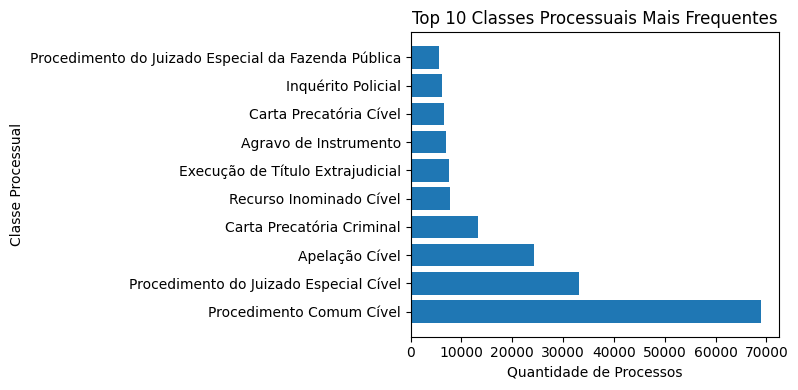

In [ ]:
# 1. Análise de Classes Processuais
top_classes = df_tjma_total['classe_processual'].value_counts().head(10)

plt.figure(figsize=(8, 4))
plt.barh(top_classes.index, top_classes.values)
plt.title('Top 10 Classes Processuais Mais Frequentes')
plt.xlabel('Quantidade de Processos')
plt.ylabel('Classe Processual')
plt.tight_layout()
plt.show()

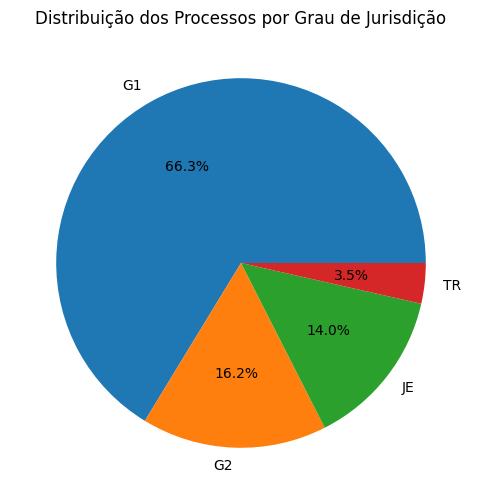

In [ ]:
# 2. Distribuição por Grau de Jurisdição
grau_counts = df_tjma_total['grau_jurisdicao'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(grau_counts, labels=grau_counts.index, autopct='%1.1f%%')
plt.title('Distribuição dos Processos por Grau de Jurisdição')
plt.show()

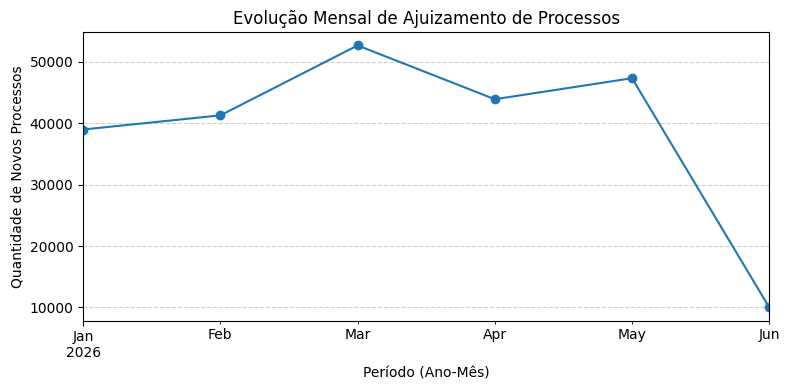

In [ ]:
# 3. Análise Temporal
# Convertendo a string para datetime (pegando apenas os 8 primeiros caracteres: AAAAMMDD)
df_tjma_total['data_ajuizamento_limpa'] = pd.to_datetime(df_tjma_total['data_ajuizamento'].astype(str).str[:8], format='%Y%m%d', errors='coerce')

# Agrupando por mês/ano para ver a evolução
processos_por_mes = df_tjma_total.groupby(df_tjma_total['data_ajuizamento_limpa'].dt.to_period('M')).size()

plt.figure(figsize=(8, 4))
processos_por_mes.plot(kind='line', marker='o')
plt.title('Evolução Mensal de Ajuizamento de Processos')
plt.xlabel('Período (Ano-Mês)')
plt.ylabel('Quantidade de Novos Processos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

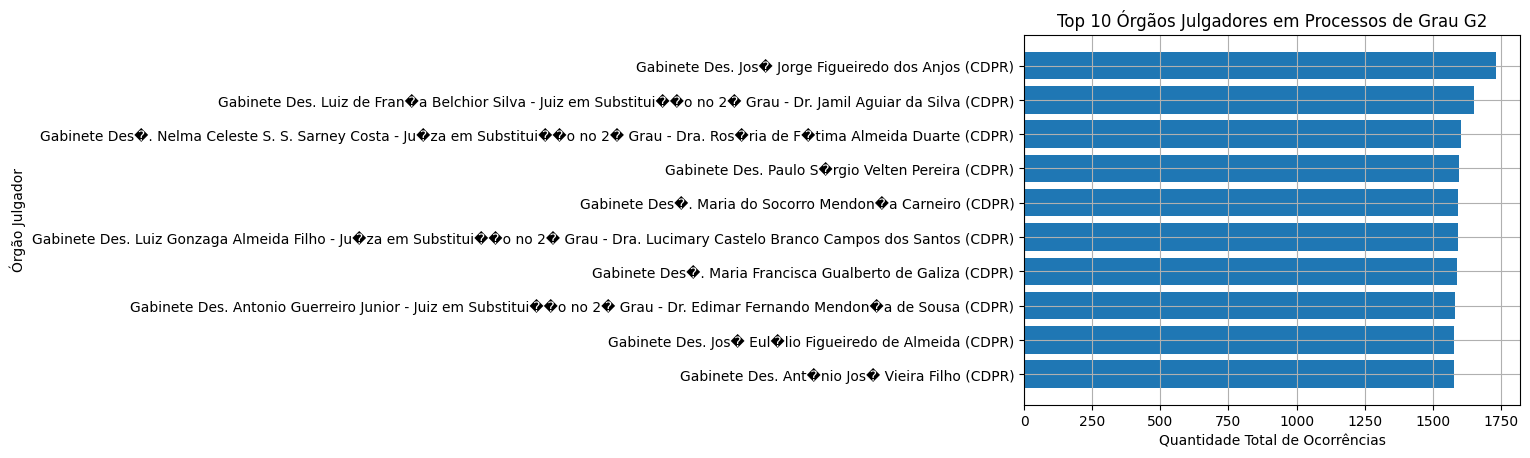

In [ ]:
# 4. Processos em G2
df_g2 = df_tjma_total[df_tjma_total['grau_jurisdicao'] == 'G2'].copy()

# Contagem de processos nos gabinetes (top 10)
top_orgaos_g2 = df_g2['orgao_julgador'].value_counts().head(10).sort_values(ascending=True)

# Plotagem do gráfico
fig, ax = plt.subplots()

ax.barh(top_orgaos_g2.index, top_orgaos_g2.values)
ax.set_title('Top 10 Órgãos Julgadores em Processos de Grau G2')
ax.set_xlabel('Quantidade Total de Ocorrências')
ax.set_ylabel('Órgão Julgador')
ax.grid(True)
plt.show()

# 9. Explodindo os "assuntos"

In [ ]:
print(df_tjma_total['assuntos'].value_counts())

assuntos
[{'codigo': 11806, 'nome': 'Empréstimo consignado'}]                                                                                                                                                               13948
[{'codigo': 15035, 'nome': 'Intimação'}]                                                                                                                                                                            8545
[{'codigo': 11807, 'nome': 'Tarifas'}]                                                                                                                                                                              8045
[{'codigo': 11811, 'nome': 'Práticas Abusivas'}]                                                                                                                                                                    4415
[{'codigo': 9582, 'nome': 'Alienação Fiduciária'}]                                                                         

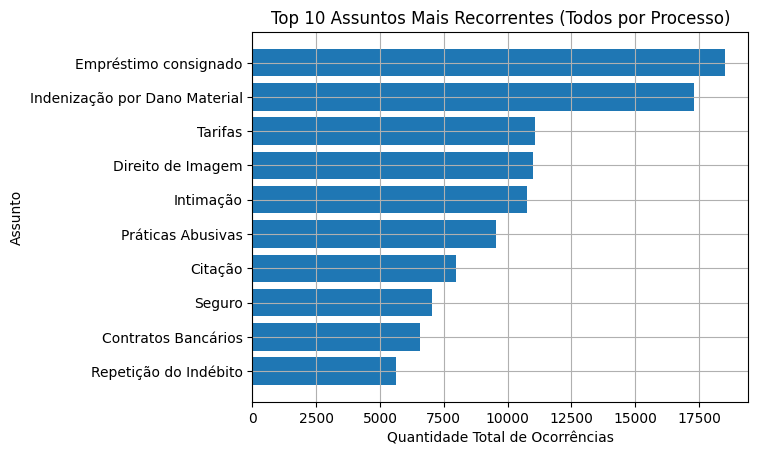

In [ ]:
# 5. Assuntos mais recorrentes

import ast # converte strings em estrutura de dados
import numpy as np # para np.nan

def extrair_todos_assuntos(lista_de_dicts):
    # Se o valor não for uma lista (e.g., NaN), retorna uma lista vazia
    if not isinstance(lista_de_dicts, list):
        return []

    nomes = []
    for item in lista_de_dicts:
        # Ajusta para itens que podem ser listas de dicionários aninhadas (ex: [[{'nome': 'Assunto'}]])
        if isinstance(item, list) and len(item) > 0 and isinstance(item[0], dict):
            actual_item = item[0]
        elif isinstance(item, dict):
            actual_item = item
        else:
            continue # Ignora itens malformados

        if 'nome' in actual_item:
            nomes.append(actual_item['nome'].strip())
    return nomes

# 1. Aplica a extração segura linha por linha
df_tjma_total['lista_assuntos'] = df_tjma_total['assuntos'].apply(extrair_todos_assuntos)

# 2. Explode a lista para contar todas as ocorrências individuais de assuntos
df_assuntos_explodido = df_tjma_total.explode('lista_assuntos')
top_assuntos_todos = df_assuntos_explodido['lista_assuntos'].value_counts().head(10).sort_values(ascending=True)

# 3. Plotagem do gráfico
fig, ax = plt.subplots()

ax.barh(top_assuntos_todos.index, top_assuntos_todos.values)
ax.set_title('Top 10 Assuntos Mais Recorrentes (Todos por Processo)')
ax.set_xlabel('Quantidade Total de Ocorrências')
ax.set_ylabel('Assunto')
ax.grid(True)

plt.show()

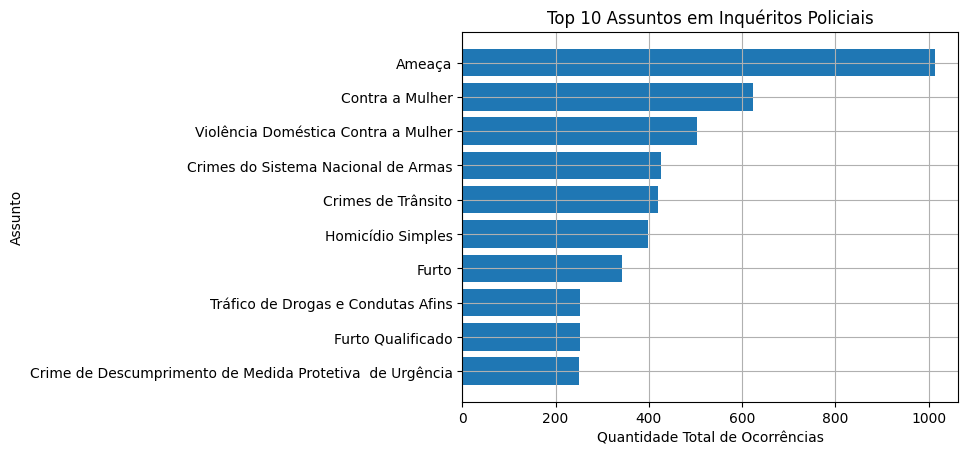

In [ ]:
# 6. Assuntos mais recorrentes em IPs

# Filtrar processos que são 'Inquérito Policial'
df_inquerito_policial = df_tjma_total[df_tjma_total['classe_processual'] == 'Inquérito Policial'].copy()

# Extrair e explodir os assuntos para esses processos
df_inquerito_policial['lista_assuntos'] = df_inquerito_policial['assuntos'].apply(extrair_todos_assuntos)
df_assuntos_inquerito_explodido = df_inquerito_policial.explode('lista_assuntos')

# Contar os 10 assuntos mais recorrentes
top_assuntos_inquerito = df_assuntos_inquerito_explodido['lista_assuntos'].value_counts().head(10).sort_values(ascending=True)

# Plotagem do gráfico
fig, ax = plt.subplots()

ax.barh(top_assuntos_inquerito.index, top_assuntos_inquerito.values)
ax.set_title('Top 10 Assuntos em Inquéritos Policiais')
ax.set_xlabel('Quantidade Total de Ocorrências')
ax.set_ylabel('Assunto')
ax.grid(True)

plt.show()